# Project notebook
## Andrés Holguín Restrepo



## Loading Libraries


In [1]:
import pandas as pd                                     # Data analysis and manipultion tool
import numpy as np                                      # Fundamental package for linear algebra and multidimensional arrays
import tensorflow as tf   
import matplotlib.pyplot as plt                              # Deep Learning Tool
from tensorflow.keras import Sequential 
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout,Flatten
import os                                               # OS module in Python provides a way of using operating system dependent functionality
import cv2                                              # Library for image processing
from sklearn.model_selection import train_test_split    # For splitting the data into train and validation set
from sklearn.metrics import f1_score

## Loading and preparing training data

Data in "eye_gender_data" was downloaded manually and then extracted to be used.


In [2]:
labels = pd.read_csv("eye_gender_data/Training_set.csv")   # loading the labels
file_paths = [[fname, 'eye_gender_data/train/' + fname] for fname in labels['filename']]
images = pd.DataFrame(file_paths, columns=['filename', 'filepaths'])
train_data = pd.merge(images, labels, how = 'inner', on = 'filename')
train_images=[]
train_labels=[]
data = []     # initialize an empty numpy array
image_size = 32      # image size taken is 100 here. one can take other size too
for i in range(len(train_data)):
  img_array = cv2.imread(train_data['filepaths'][i], cv2.IMREAD_GRAYSCALE)   # converting the image to gray scale
  new_img_array = cv2.resize(img_array, (image_size, image_size))      # resizing the image array
  data.append([new_img_array, train_data['label'][i]])
  train_images.append(new_img_array)
  if train_data['label'][i]=='female':
    train_labels.append(0)
  else:
    train_labels.append(1)

## Data Pre-processing
Train data as np arrays and normalization of images

In [3]:
train_images=np.array(train_images)/255
train_labels=np.array(train_labels)

## Building Model, Hyperparameter tuning & Validation


In [7]:
train_images_3ch = np.stack([train_images]*3, axis=-1)
INPUT_SHAPE = (image_size, image_size, 3)
print('\nTrain_images.shape: {}, of {}'.format(train_images_3ch.shape, train_images_3ch.dtype))


Train_images.shape: (9220, 32, 32, 3), of float64


In [8]:
vgg_layers = tf.keras.applications.vgg19.VGG19(weights='imagenet', include_top=False, 
                                               input_shape=INPUT_SHAPE)


# Fine-tune all the layers
for layer in vgg_layers.layers:
    layer.trainable = True

vgg_layers.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 32, 32, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 32, 32, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 16, 16, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 16, 16, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 16, 16, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 8, 8, 128)         0     

In [12]:
# define sequential model
model = tf.keras.models.Sequential()

# Add the vgg convolutional base model
model.add(vgg_layers)

# add flatten layer
model.add(tf.keras.layers.Flatten())

# add dense layers with some dropout
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.3))
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.3))

# add output layer
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5), 
              loss='BinaryCrossentropy', 
              metrics=['accuracy'])

# view model layers
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 1, 1, 512)         20024384  
                                                                 
 flatten_2 (Flatten)         (None, 512)               0         
                                                                 
 dense_6 (Dense)             (None, 256)               131328    
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 256)               65792     
                                                                 
 dropout_5 (Dropout)         (None, 256)               0         
                                                                 
 dense_8 (Dense)             (None, 1)                

In [13]:
EPOCHS = 100
es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, 
                                               restore_best_weights=True,
                                               verbose=1)

history = model.fit(train_images_3ch, train_labels,
                    batch_size=50,
                    callbacks=[es_callback], 
                    validation_split=0.1, epochs=EPOCHS,
                    verbose=1)

Epoch 1/100
260/260 [==============================] - 220s 843ms/step - loss: 0.4188 - accuracy: 0.7971 - val_loss: 0.2747 - val_accuracy: 0.8905
Epoch 2/100
260/260 [==============================] - 224s 863ms/step - loss: 0.2183 - accuracy: 0.9171 - val_loss: 0.2453 - val_accuracy: 0.8991
Epoch 3/100
260/260 [==============================] - 222s 854ms/step - loss: 0.1677 - accuracy: 0.9364 - val_loss: 0.1878 - val_accuracy: 0.9295
Epoch 4/100
260/260 [==============================] - 223s 856ms/step - loss: 0.1397 - accuracy: 0.9471 - val_loss: 0.1620 - val_accuracy: 0.9403
Epoch 5/100
260/260 [==============================] - 234s 898ms/step - loss: 0.1117 - accuracy: 0.9587 - val_loss: 0.1741 - val_accuracy: 0.9403
Epoch 6/100
260/260 [==============================] - 227s 872ms/step - loss: 0.0922 - accuracy: 0.9651 - val_loss: 0.1750 - val_accuracy: 0.9447
Epoch 6: early stopping


<AxesSubplot:>

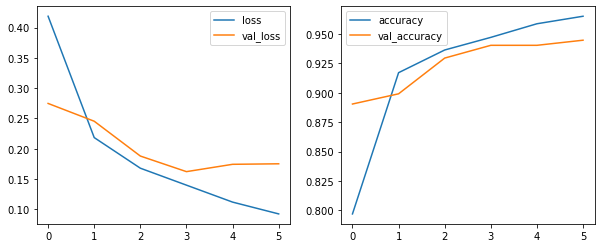

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

history_df = pd.DataFrame(history.history)
history_df[['loss', 'val_loss']].plot(kind='line', ax=ax[0])
history_df[['accuracy', 'val_accuracy']].plot(kind='line', ax=ax[1])

## Test prediction


#### Load Test Set

In [38]:
labels = pd.read_csv("eye_gender_data/Testing_set.csv")   # loading the labels
file_paths = [[fname, 'eye_gender_data/test/' + fname] for fname in labels['filename']]
images = pd.DataFrame(file_paths, columns=['filename', 'filepaths'])
test_data = pd.merge(images, labels, how = 'inner', on = 'filename')
test_images=[]
train_labels=[]
for i in range(len(test_data)):
  img_array = cv2.imread(test_data['filepaths'][i], cv2.IMREAD_GRAYSCALE)   # converting the image to gray scale
  test_images.append(cv2.resize(img_array, (image_size, image_size)))      # resizing the image array

## Data Pre-processing on test_data


In [39]:
INPUT_SHAPE = (image_size, image_size, 3)
test_images=np.array(test_images)/255
test_images_3ch = np.stack([test_images]*3, axis=-1)

print('Test_images.shape: {}, of {}'.format(test_images_3ch.shape, test_images_3ch.dtype))

Test_images.shape: (2305, 32, 32, 3), of float64


### Make Prediction on Test Dataset
Time to make a submission!!!

In [58]:
predictions = model.predict(test_images_3ch)
predictions = np.rint(predictions)

In [61]:
prediction_labels=[]
for i in range (len(predictions)):
    if predictions[i]:
        prediction_labels.append('male')
    else:
        prediction_labels.append('female')

'male'

## Save CVV

In [63]:
res = pd.DataFrame({ 'label': prediction_labels})  # prediction is nothing but the final predictions of your model on input features of your new unseen test data
res.to_csv("submission.csv", index = False)      # the csv file will be saved locally on the same location where this notebook is located.